The first three headings:
                                             name rating      genre  year  \
0                                     The Shining      R      Drama  1980   
1                                 The Blue Lagoon      R  Adventure  1980   
2  Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   

                        released  score    votes         director  \
0  June 13, 1980 (United States)    8.4   927000  Stanley Kubrick   
1   July 2, 1980 (United States)    5.8    65000   Randal Kleiser   
2  June 20, 1980 (United States)    8.7  1200000   Irvin Kershner   

                    writer            star         country    budget  \
0             Stephen King  Jack Nicholson  United Kingdom  19000000   
1  Henry De Vere Stacpoole  Brooke Shields   United States   4500000   
2           Leigh Brackett     Mark Hamill   United States  18000000   

         gross            company runtime,,  
0   46998772.0       Warner Bros.    146.0,  
1   588

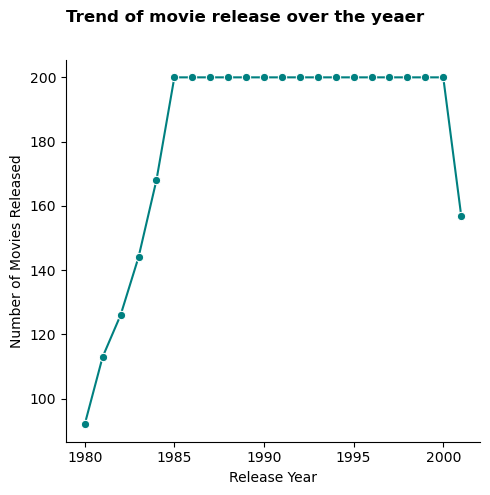

Top ten genres movies:
       genre  genre_movie_count
0     Comedy               1355
1      Drama                807
2     Action                775
3      Crime                302
4  Adventure                231
5  Biography                175
6     Horror                158
7  Animation                113
8    Fantasy                 33
9    Mystery                 13


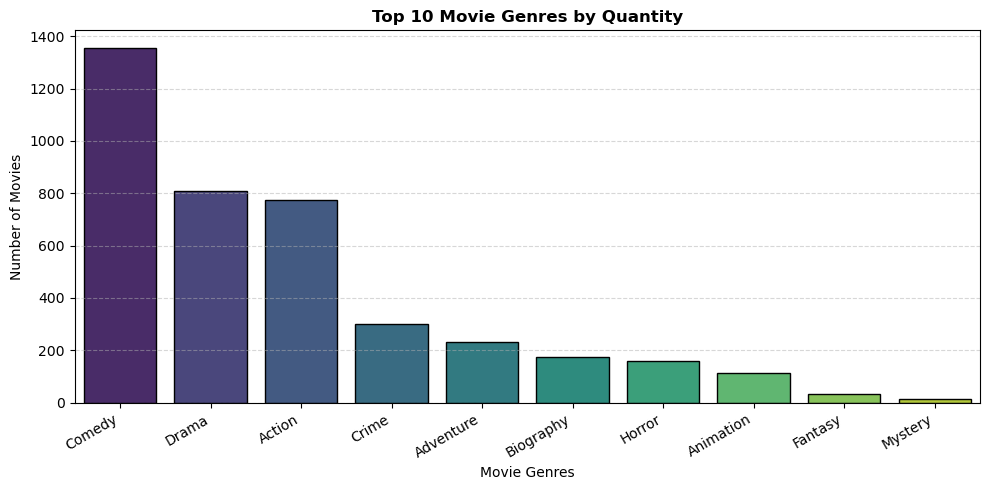

Top ten directors :
           director  movie_count
0       Woody Allen           22
1         Directors           16
2    Barry Levinson           16
3    Clint Eastwood           16
4   Joel Schumacher           15
5       Walter Hill           15
6      Sidney Lumet           15
7        Ron Howard           14
8  Steven Spielberg           14
9    John Carpenter           14


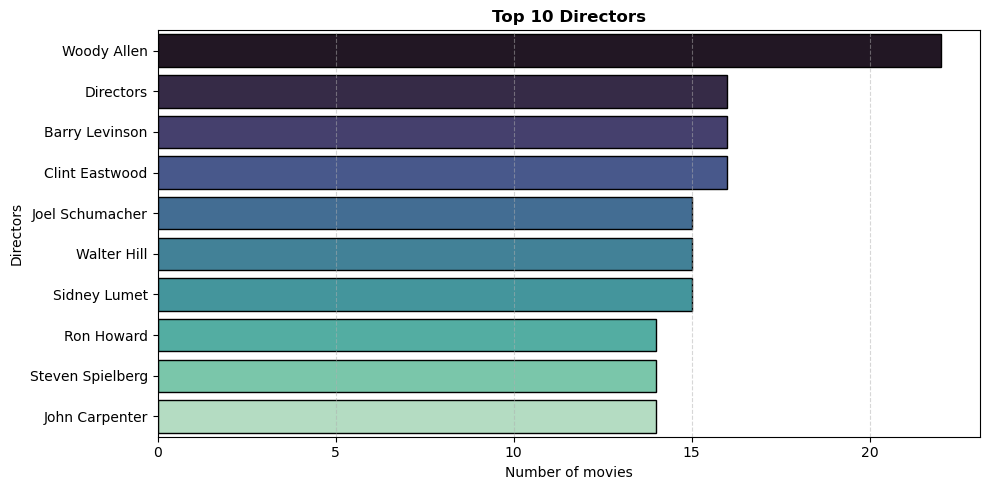

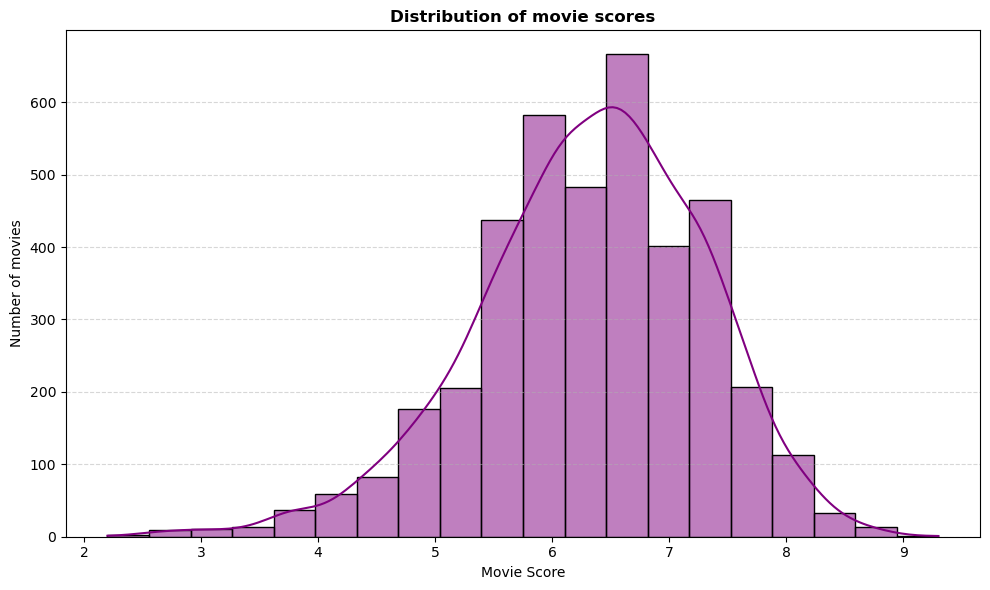

        genre     score
9     History  8.300000
11      Music  7.200000
3   Biography  7.052000
2   Animation  6.883186
6       Drama  6.673606
5       Crime  6.645033
7      Family  6.550000
12    Mystery  6.500000
13    Romance  6.400000
4      Comedy  6.179410
1   Adventure  6.151948
8     Fantasy  6.024242
0      Action  6.014968
14     Sci-Fi  5.983333
15   Thriller  5.890909
10     Horror  5.744304
16    Western  5.666667


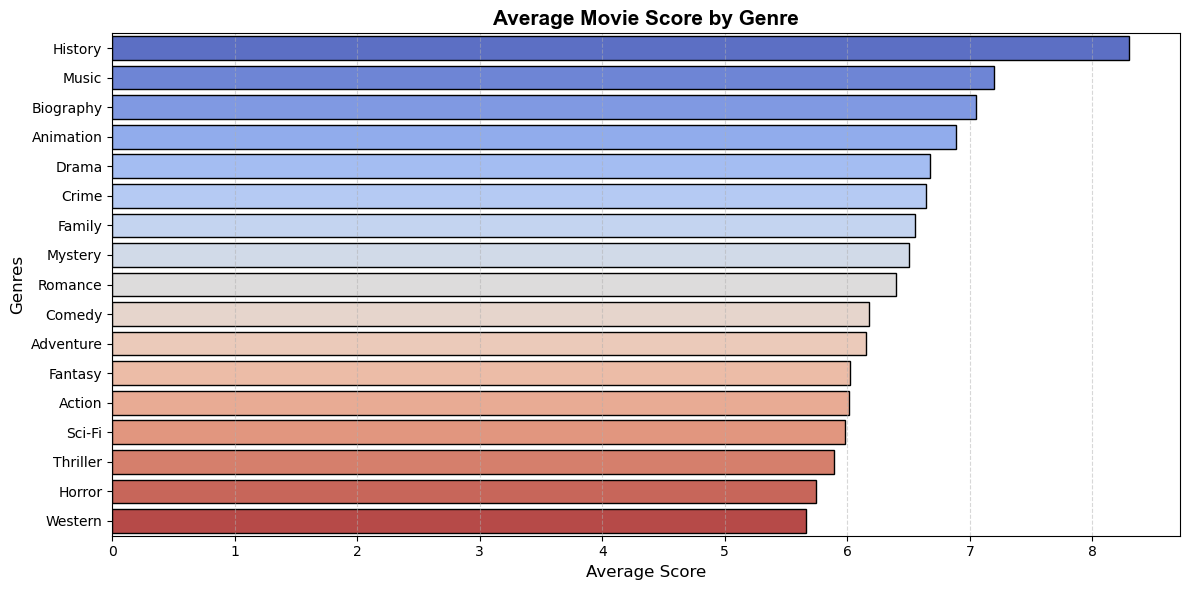

                                                   name         gross
3045                                            Titanic  2.201647e+09
2448                                      The Lion King  1.083721e+09
2245                                      Jurassic Park  1.033928e+09
3451          Star Wars: Episode I - The Phantom Menace  1.027083e+09
3843              Harry Potter and the Sorcerer's Stone  1.006968e+09
3845  The Lord of the Rings: The Fellowship of the Ring  8.976901e+08
2844                                   Independence Day  8.174009e+08
209                          E.T. the Extra-Terrestrial  7.929106e+08
2445                                       Forrest Gump  6.782261e+08
3453                                    The Sixth Sense  6.728063e+08


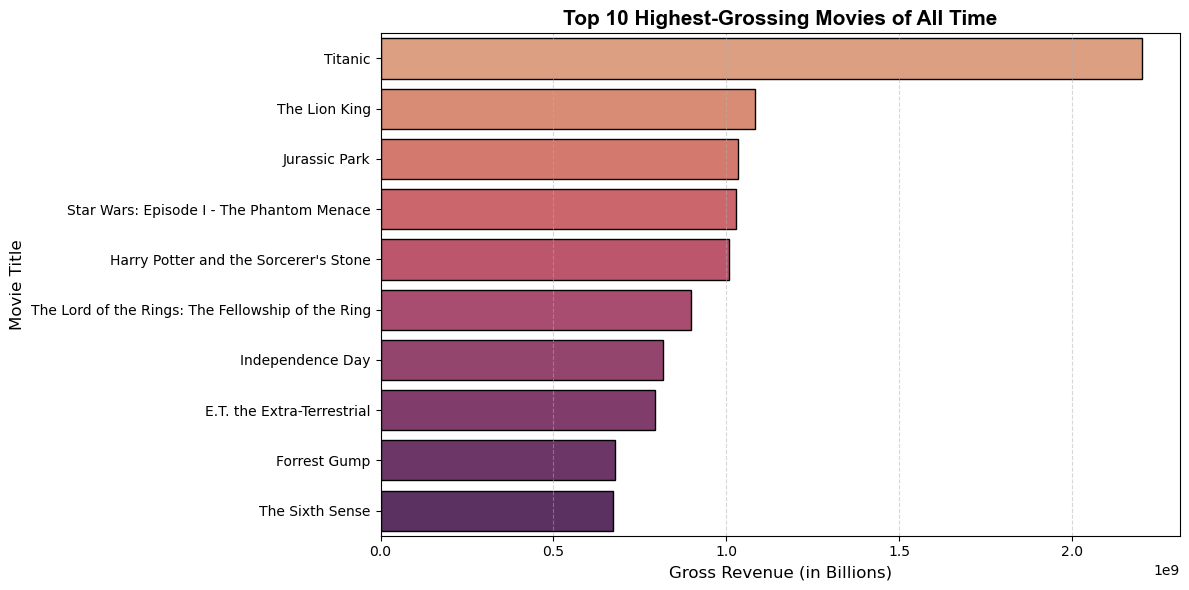

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading dataset from file
file_path=r"C:\Users\USER\Desktop\Data Science\movie-file/movies_updated.csv"
movies=pd.read_csv(file_path)

# Task 1: Explore the Dataset

print(f"The first three headings:\n{movies.head(3)}")
print("*"*50)
print(f"Movies info :\n{movies.info()}")
print("*"*50)
print(movies.describe())
print("*"*50)
#Total movies
total_movies=len(movies)
print(f"Total moveis in the file are:{total_movies}")
print("*"*50)
#Selecting the numerical columns
numerical_cols=movies.select_dtypes(include=['int64','float64'])
numerical_cols_list=numerical_cols.columns.tolist()
print(f"Numerical Columns:\n{numerical_cols_list}")
print("*"*50)
#Categorical columns
categorical_cols=movies.select_dtypes(include=['object','category'])
categorical_cols_list=categorical_cols.columns.tolist()
print(f"categorical columns:\n{categorical_cols_list}")
print("*"*50)

#Task 2: Number of Movies Released Each Year

movies_per_year = movies.groupby('year').size().reset_index(name='movie_count')
print(f"Movies released on each year:\n{movies_per_year}")
g=sns.relplot(
    data=movies_per_year,
    x="year",
    y="movie_count",
    kind="line",
    color="teal",
    marker="o"
)
g.fig.suptitle("Trend of movie release over the yeaer", fontsize=12, fontweight="bold")
g.fig.subplots_adjust(top=0.88)
g.set_axis_labels("Release Year", "Number of Movies Released")
plt.show()

# Task 3: Top 10 Movie Genres
genre_movies=movies['genre'].dropna().str.split(', ').explode()
genre_movies_count=genre_movies.value_counts().reset_index(name="genre_movie_count")
genre_movies_count.columns=['genre','genre_movie_count']

top_ten_genres=genre_movies_count.head(10)
print(f"Top ten genres movies:\n{top_ten_genres}")
fig, ax=plt.subplots(figsize=(10,5))
sns.barplot(
    data=top_ten_genres,
    x="genre",
    y="genre_movie_count",
    palette="viridis",
    hue="genre",
    edgecolor="black",
    ax=ax,
    legend=False
)
ax.set_title("Top 10 Movie Genres by Quantity", fontsize=12,fontweight="bold")
ax.set_xlabel("Movie Genres", fontsize=10)
ax.set_ylabel("Number of Movies", fontsize=10)
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()
             

# Task 4: Top 10 Directors
director_count=movies['director'].dropna().value_counts().reset_index(name="movie_count")
dirctor_count_columns=['director', 'movie_count']
top_ten_directors=director_count.head(10)
print(f"Top ten directors :\n{top_ten_directors}")
fig, ax=plt.subplots(figsize=(10,5))
sns.barplot(
    data=top_ten_directors,
    x="movie_count",
    y="director",
    palette="mako",
     hue="director",
    edgecolor="black",
    ax=ax
)
ax.set_title("Top 10 Directors", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of movies", fontsize=10)
ax.set_ylabel("Directors", fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Task 5: Distribution of Movie Ratings

fig, ax=plt.subplots(figsize=(10,6))
sns.histplot(
    data=movies,
    x="score",
    bins=20,
    kde=True,
    color="purple",
    edgecolor="black",
    ax=ax
)
ax.set_title("Distribution of movie scores", fontsize=12, fontweight="bold")
ax.set_xlabel("Movie Score", fontsize=10)
ax.set_ylabel("Number of movies", fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
    
# Task 6: Average Movie Score by Genre

df['genre'] = df['genre'].dropna()
genres_expanded = df.assign(genre=df['genre'].str.split(', ')).explode('genre')

# Group by genre and calculate the mean score
genre_means = genres_expanded.groupby('genre')['score'].mean().reset_index()

# 3. Sort from highest average score to lowest
genre_means_sorted = genre_means.sort_values(by='score', ascending=False)
print(genre_means_sorted) # View the precise numeric leaderboard in your console

# 4. Create the bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal bar chart is perfect here to easily read genre names
sns.barplot(
    data=genre_means_sorted,
    x='score',
    y='genre',
    hue="genre",
    palette='coolwarm',
    edgecolor='black',
    ax=ax
)

# 5. Titles and Formatting
ax.set_title("Average Movie Score by Genre", fontsize=15, fontweight='bold', fontfamily='arial')
ax.set_xlabel("Average Score", fontsize=12)
ax.set_ylabel("Genres", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


# Task 7: Top 10 Highest Grossing Movies

df_cleaned = df.dropna(subset=['gross'])

# Sort from highest revenue to lowest and get the Top 10
top_10_grossing = df_cleaned.sort_values(by='gross', ascending=False).head(10)
print(top_10_grossing[['name', 'gross']]) # View numbers in your console

# 3. Create the HORIZONTAL bar chart
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_10_grossing, 
    x='gross', 
    y='name', 
    hue="name",
    palette='flare', 
    edgecolor='black',
    ax=ax
)

# 4. Format titles and labels
ax.set_title("Top 10 Highest-Grossing Movies of All Time", fontsize=15, fontweight='bold', fontfamily='arial')
ax.set_xlabel("Gross Revenue (in Billions)", fontsize=12)
ax.set_ylabel("Movie Title", fontsize=12)

# Clean up layout
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()



# Final question, Report



# To: Executive Leadership Team

# From: Data Analytics Team

# Subject: Strategic Insights & Market Trend Analysis Report

# Our comprehensive market analysis reveals that while Comedy and Action are the most common genres
# produced by quantity, they do not hold the highest critical acclaim;
# instead, niche genres like Documentaries and Biographies consistently
# secure the highest average ratings. Looking at overall consumer 
# sentiment, the majority of movies cluster around an average-to-good 
# score of 6.5, proving that while truly terrible movies are rare,
# exceptionally high-rated films are equally unique. Production volume 
# has steadily increased over the years, demonstrating a growing, highly
# competitive market. Financially, major franchise blockbusters dominate 
# the leaderboard, with [Insert Highest Movie Title Here] securing the 
# absolute highest gross revenue.

# Strategic Recommendations:
# The "Barbell" Strategy: The studio should balance its portfolio by funding high-budget, 
#     action-driven franchise films to capture massive box office revenue,
#     while simultaneously investing in lower-budget, high-quality biographical
#     or documentary features to reliably win critical acclaim and awards.

# Capitalize on Market Growth: Since global production is rising, the 
#     studio must prioritize unique storytelling or established i
#     ntellectual property (IP) to stand out in an increasingly crowded marketplace.